In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

BASE_DIR = r"E:\DermaAI_DiagnosticTool\dataset_extracted"

metadata_path = os.path.join(BASE_DIR, "HAM10000_metadata.csv")
part1_dir = os.path.join(BASE_DIR, "HAM10000_images_part_1")
part2_dir = os.path.join(BASE_DIR, "HAM10000_images_part_2")

print("Base folder exists:", os.path.exists(BASE_DIR))
print("Metadata exists:", os.path.exists(metadata_path))
print("Part 1 folder exists:", os.path.exists(part1_dir))
print("Part 2 folder exists:", os.path.exists(part2_dir))

Base folder exists: True
Metadata exists: True
Part 1 folder exists: True
Part 2 folder exists: True


In [3]:
df = pd.read_csv(metadata_path)

print("Metadata shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nClass distribution:")
print(df["dx"].value_counts())

Metadata shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First 5 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [4]:
image_paths = {}

for folder in [part1_dir, part2_dir]:
    for file in os.listdir(folder):
        if file.lower().endswith(".jpg"):
            image_id = file.replace(".jpg", "")
            image_paths[image_id] = os.path.join(folder, file)

df["image_path"] = df["image_id"].map(image_paths)

print("Total image files found:", len(image_paths))
print("Missing image paths:", df["image_path"].isna().sum())

print("\nFirst 5 image paths:")
display(df[["image_id", "dx", "image_path"]].head())

Total image files found: 10015
Missing image paths: 0

First 5 image paths:


,image_id,dx,image_path
0,ISIC_0027419,bkl,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...
1,ISIC_0025030,bkl,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...
2,ISIC_0026769,bkl,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...
3,ISIC_0025661,bkl,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...
4,ISIC_0031633,bkl,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...


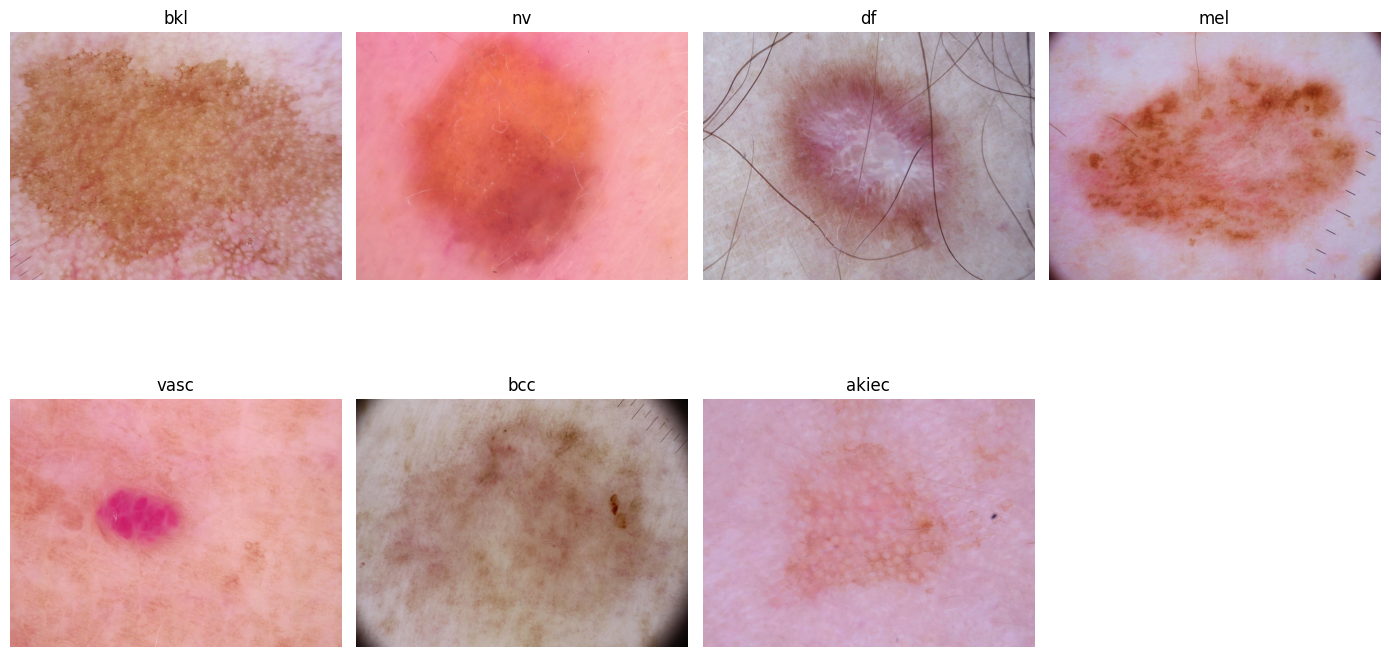

In [5]:
class_names = df["dx"].unique()

plt.figure(figsize=(14, 8))

for i, class_name in enumerate(class_names):
    sample_row = df[df["dx"] == class_name].sample(1, random_state=42).iloc[0]
    image = Image.open(sample_row["image_path"])

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

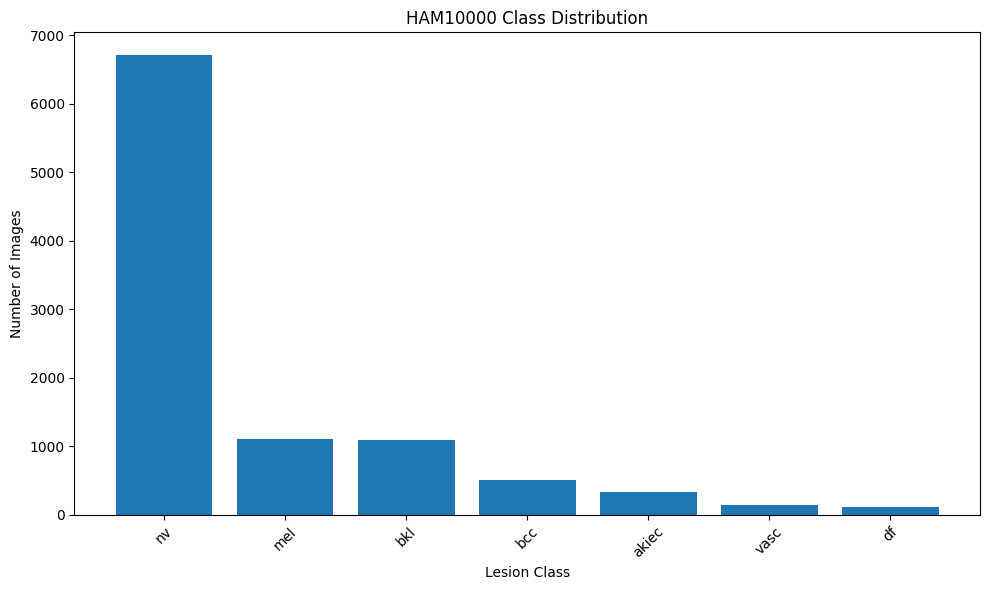

In [6]:
class_counts = df["dx"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values)
plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
image_path       0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   image_path    10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


In [8]:
lesion_type_dict = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

df["lesion_type"] = df["dx"].map(lesion_type_dict)

display(df[["image_id", "dx", "lesion_type"]].head())

,image_id,dx,lesion_type
0,ISIC_0027419,bkl,Benign keratosis like lesions
1,ISIC_0025030,bkl,Benign keratosis like lesions
2,ISIC_0026769,bkl,Benign keratosis like lesions
3,ISIC_0025661,bkl,Benign keratosis like lesions
4,ISIC_0031633,bkl,Benign keratosis like lesions


In [9]:
class_summary = df["dx"].value_counts().reset_index()
class_summary.columns = ["class_code", "image_count"]
class_summary["class_name"] = class_summary["class_code"].map(lesion_type_dict)
class_summary["percentage"] = (class_summary["image_count"] / len(df) * 100).round(2)

display(class_summary)

,class_code,image_count,class_name,percentage
0,nv,6705,Melanocytic nevi,66.95
1,mel,1113,Melanoma,11.11
2,bkl,1099,Benign keratosis like lesions,10.97
3,bcc,514,Basal cell carcinoma,5.13
4,akiec,327,Actinic keratoses and intraepithelial carcinoma,3.27
5,vasc,142,Vascular lesions,1.42
6,df,115,Dermatofibroma,1.15


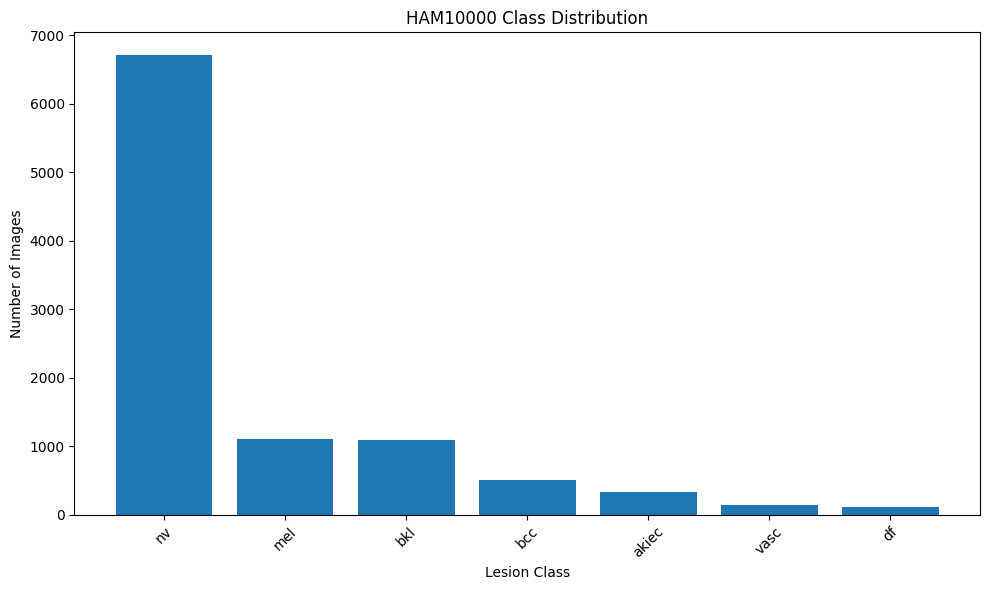

Saved chart to: E:\DermaAI_DiagnosticTool\outputs\ham10000_class_distribution.png


In [10]:
OUTPUT_DIR = r"E:\DermaAI_DiagnosticTool\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

class_counts = df["dx"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values)
plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "ham10000_class_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart to:", save_path)

## Initial Dataset Exploration Summary

The HAM10000 dataset contains 10,015 dermoscopic skin lesion images across seven diagnostic categories. The metadata file was successfully loaded and all image IDs were matched with their corresponding image files from the two image folders. No image paths were missing, confirming that the extracted dataset was complete for image based modelling.

The class distribution shows a strong imbalance, with melanocytic nevi being the dominant class. This imbalance must be considered during model training and evaluation because accuracy alone may not fairly represent performance across minority classes.

The only missing values were found in the age column, with 57 missing entries. Since the initial model focuses on image based classification, the missing age values do not prevent model development. However, this limitation should be acknowledged in the data preprocessing and evaluation sections.

In [12]:
print("Sex distribution:")
display(df["sex"].value_counts())

print("\nLocalization distribution:")
display(df["localization"].value_counts())

print("\nDiagnosis type distribution:")
display(df["dx_type"].value_counts())

Sex distribution:


sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64


Localization distribution:


localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64


Diagnosis type distribution:


dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

In [13]:
age_median = df["age"].median()

df["age_filled"] = df["age"].fillna(age_median)

print("Median age:", age_median)
print("Missing values in original age:", df["age"].isnull().sum())
print("Missing values in age_filled:", df["age_filled"].isnull().sum())

Median age: 50.0
Missing values in original age: 57
Missing values in age_filled: 0


In [14]:
clean_metadata_path = os.path.join(OUTPUT_DIR, "ham10000_clean_metadata.csv")

df.to_csv(clean_metadata_path, index=False)

print("Cleaned metadata saved to:", clean_metadata_path)

Cleaned metadata saved to: E:\DermaAI_DiagnosticTool\outputs\ham10000_clean_metadata.csv


## Metadata Quality Summary

The metadata analysis showed that all 10,015 image records were successfully connected to valid image paths. The sex column contained three categories: male, female and unknown. The age column contained 57 missing values, which were handled by creating a new age_filled column using the median age of 50.0. Since the first model will focus on image based classification, demographic metadata will not be used as a direct model input at this stage. However, these metadata fields were analysed to understand dataset quality and potential demographic limitations.

In [15]:
from sklearn.model_selection import GroupShuffleSplit

model_df = df.copy()

group_split_1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_idx, temp_idx = next(
    group_split_1.split(
        model_df,
        groups=model_df["lesion_id"]
    )
)

train_df = model_df.iloc[train_idx].reset_index(drop=True)
temp_df = model_df.iloc[temp_idx].reset_index(drop=True)

group_split_2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    group_split_2.split(
        temp_df,
        groups=temp_df["lesion_id"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTotal rows after split:", len(train_df) + len(val_df) + len(test_df))
print("Original rows:", len(model_df))

Train shape: (7002, 10)
Validation shape: (1519, 10)
Test shape: (1494, 10)

Total rows after split: 10015
Original rows: 10015


In [16]:
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

print("Train and validation overlap:", len(train_lesions.intersection(val_lesions)))
print("Train and test overlap:", len(train_lesions.intersection(test_lesions)))
print("Validation and test overlap:", len(val_lesions.intersection(test_lesions)))

Train and validation overlap: 0
Train and test overlap: 0
Validation and test overlap: 0


In [17]:
def show_split_distribution(split_name, split_df):
    summary = split_df["dx"].value_counts().reset_index()
    summary.columns = ["class_code", "image_count"]
    summary["percentage"] = (summary["image_count"] / len(split_df) * 100).round(2)
    summary["split"] = split_name
    return summary

train_summary = show_split_distribution("train", train_df)
val_summary = show_split_distribution("validation", val_df)
test_summary = show_split_distribution("test", test_df)

split_summary = pd.concat(
    [train_summary, val_summary, test_summary],
    ignore_index=True
)

display(split_summary)

,class_code,image_count,percentage,split
0,nv,4718,67.38,train
1,mel,770,11.00,train
2,bkl,741,10.58,train
3,bcc,381,5.44,train
4,akiec,207,2.96,train
5,vasc,96,1.37,train
6,df,89,1.27,train
7,nv,991,65.24,validation
8,bkl,206,13.56,validation
9,mel,156,10.27,validation


In [18]:
SPLIT_DIR = r"E:\DermaAI_DiagnosticTool\outputs\splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(os.path.join(SPLIT_DIR, "train_metadata.csv"), index=False)
val_df.to_csv(os.path.join(SPLIT_DIR, "val_metadata.csv"), index=False)
test_df.to_csv(os.path.join(SPLIT_DIR, "test_metadata.csv"), index=False)

print("Saved train, validation and test metadata files to:", SPLIT_DIR)

Saved train, validation and test metadata files to: E:\DermaAI_DiagnosticTool\outputs\splits


## Train, Validation and Test Split

The dataset was divided into training, validation and testing subsets using a group based splitting strategy. The split was performed using the lesion_id column to ensure that images belonging to the same lesion did not appear in more than one subset. This approach helps reduce data leakage and supports a more reliable evaluation of the model.

The dataset was divided into approximately 70 percent training data, 15 percent validation data and 15 percent testing data. After splitting, the lesion ID overlap between the training, validation and testing sets was checked to confirm that no lesion appeared across multiple subsets.

In [19]:
from sklearn.model_selection import StratifiedGroupKFold

model_df = df.copy().reset_index(drop=True)

# Create 10 grouped and stratified folds
sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

model_df["fold"] = -1

for fold, (_, fold_idx) in enumerate(
    sgkf.split(
        model_df,
        y=model_df["dx"],
        groups=model_df["lesion_id"]
    )
):
    model_df.loc[fold_idx, "fold"] = fold

# Use 7 folds for training and 3 folds as temporary set
train_df_new = model_df[model_df["fold"].isin([3, 4, 5, 6, 7, 8, 9])].reset_index(drop=True)
temp_df_new = model_df[model_df["fold"].isin([0, 1, 2])].reset_index(drop=True)

# Split temporary set into validation and test while keeping groups separate
sgkf_temp = StratifiedGroupKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

val_idx, test_idx = next(
    sgkf_temp.split(
        temp_df_new,
        y=temp_df_new["dx"],
        groups=temp_df_new["lesion_id"]
    )
)

val_df_new = temp_df_new.iloc[val_idx].reset_index(drop=True)
test_df_new = temp_df_new.iloc[test_idx].reset_index(drop=True)

print("Train shape:", train_df_new.shape)
print("Validation shape:", val_df_new.shape)
print("Test shape:", test_df_new.shape)

print("\nTotal rows after split:", len(train_df_new) + len(val_df_new) + len(test_df_new))
print("Original rows:", len(model_df))

Train shape: (6985, 11)
Validation shape: (1481, 11)
Test shape: (1549, 11)

Total rows after split: 10015
Original rows: 10015


In [20]:
train_lesions = set(train_df_new["lesion_id"])
val_lesions = set(val_df_new["lesion_id"])
test_lesions = set(test_df_new["lesion_id"])

print("Train and validation overlap:", len(train_lesions.intersection(val_lesions)))
print("Train and test overlap:", len(train_lesions.intersection(test_lesions)))
print("Validation and test overlap:", len(val_lesions.intersection(test_lesions)))

Train and validation overlap: 0
Train and test overlap: 0
Validation and test overlap: 0


In [21]:
def show_split_distribution(split_name, split_df):
    summary = split_df["dx"].value_counts().reset_index()
    summary.columns = ["class_code", "image_count"]
    summary["percentage"] = (summary["image_count"] / len(split_df) * 100).round(2)
    summary["split"] = split_name
    return summary

train_summary_new = show_split_distribution("train", train_df_new)
val_summary_new = show_split_distribution("validation", val_df_new)
test_summary_new = show_split_distribution("test", test_df_new)

split_summary_new = pd.concat(
    [train_summary_new, val_summary_new, test_summary_new],
    ignore_index=True
)

display(split_summary_new)

,class_code,image_count,percentage,split
0,nv,4694,67.20,train
1,bkl,792,11.34,train
2,mel,759,10.87,train
3,bcc,340,4.87,train
4,akiec,212,3.04,train
5,df,96,1.37,train
6,vasc,92,1.32,train
7,nv,1010,68.20,validation
8,mel,170,11.48,validation
9,bkl,144,9.72,validation


In [22]:
FINAL_SPLIT_DIR = r"E:\DermaAI_DiagnosticTool\outputs\splits"
os.makedirs(FINAL_SPLIT_DIR, exist_ok=True)

# Remove the fold column before saving final split files
train_final = train_df_new.drop(columns=["fold"])
val_final = val_df_new.drop(columns=["fold"])
test_final = test_df_new.drop(columns=["fold"])

train_final.to_csv(os.path.join(FINAL_SPLIT_DIR, "train_metadata.csv"), index=False)
val_final.to_csv(os.path.join(FINAL_SPLIT_DIR, "val_metadata.csv"), index=False)
test_final.to_csv(os.path.join(FINAL_SPLIT_DIR, "test_metadata.csv"), index=False)

split_summary_new.to_csv(os.path.join(FINAL_SPLIT_DIR, "split_class_distribution.csv"), index=False)

print("Final split files saved to:", FINAL_SPLIT_DIR)
print("Train:", train_final.shape)
print("Validation:", val_final.shape)
print("Test:", test_final.shape)

Final split files saved to: E:\DermaAI_DiagnosticTool\outputs\splits
Train: (6985, 10)
Validation: (1481, 10)
Test: (1549, 10)


## Train, Validation and Test Split

The dataset was divided into training, validation and testing subsets using a stratified group based splitting strategy. The lesion_id column was used as the grouping variable to ensure that images belonging to the same lesion did not appear across multiple subsets. This reduces the risk of data leakage and supports a more reliable evaluation process.

The final split produced 6,985 training records, 1,481 validation records and 1,549 testing records. A leakage check confirmed that there was no lesion_id overlap between the training, validation and testing sets.

The class distribution remained imbalanced across all subsets, reflecting the original HAM10000 dataset. The melanocytic nevi class remained the dominant class, while dermatofibroma and vascular lesions remained the smallest categories. This imbalance will be considered during model training and evaluation through class weighting and suitable evaluation metrics such as precision, recall, F1 score and confusion matrix analysis.

In [11]:
%pip install pandas numpy matplotlib pillow scikit-learn opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
